# Subgroup Performance Analysis

### Goals:
- Take the predictions by our best model (M6 MLP CF=16), extract them and the path
- Merge with the real demographic ground truths
- Recalculate metrics and plot AUC curves for the different subgroups vs the baseline

> We want to show that our model outperforms teh baseline particularly well for the worst groups.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve

In [4]:
# Load fold prediction (cross fold) test sets
folds = [0, 1, 2, 3, 4]
fold_path = '/zhome/d0/a/221493/thesis/results/C2_custom/effusion/cv_results/cf_16/fold_{FOLD}_predictions.csv'

full_df = pd.DataFrame()

for fold in folds:
    fold_df = pd.read_csv(fold_path.format(FOLD=fold))
    full_df = pd.concat([full_df, fold_df], ignore_index=True)
    print("Loaded fold {} with shape {}".format(fold, fold_df.shape))
    
print("All folds loaded successfully.")

Loaded fold 0 with shape (9031, 1989)
Loaded fold 1 with shape (9031, 1989)
Loaded fold 2 with shape (9031, 1989)
Loaded fold 3 with shape (9031, 1989)
Loaded fold 4 with shape (9031, 1989)
All folds loaded successfully.


In [5]:
for column in full_df.columns:
    print(column)

path
effusion_prob
effusion_true
emb_0
emb_1
emb_2
emb_3
emb_4
emb_5
emb_6
emb_7
emb_8
emb_9
emb_10
emb_11
emb_12
emb_13
emb_14
emb_15
emb_16
emb_17
emb_18
emb_19
emb_20
emb_21
emb_22
emb_23
emb_24
emb_25
emb_26
emb_27
emb_28
emb_29
emb_30
emb_31
emb_32
emb_33
emb_34
emb_35
emb_36
emb_37
emb_38
emb_39
emb_40
emb_41
emb_42
emb_43
emb_44
emb_45
emb_46
emb_47
emb_48
emb_49
emb_50
emb_51
emb_52
emb_53
emb_54
emb_55
emb_56
emb_57
emb_58
emb_59
emb_60
emb_61
emb_62
emb_63
emb_64
emb_65
emb_66
emb_67
emb_68
emb_69
emb_70
emb_71
emb_72
emb_73
emb_74
emb_75
emb_76
emb_77
emb_78
emb_79
emb_80
emb_81
emb_82
emb_83
emb_84
emb_85
emb_86
emb_87
emb_88
emb_89
emb_90
emb_91
emb_92
emb_93
emb_94
emb_95
emb_96
emb_97
emb_98
emb_99
emb_100
emb_101
emb_102
emb_103
emb_104
emb_105
emb_106
emb_107
emb_108
emb_109
emb_110
emb_111
emb_112
emb_113
emb_114
emb_115
emb_116
emb_117
emb_118
emb_119
emb_120
emb_121
emb_122
emb_123
emb_124
emb_125
emb_126
emb_127
emb_128
emb_129
emb_130
emb_131
emb_132
emb_133
emb_1

In [42]:
# Extract columns
columns_to_extract = ['path', 'effusion_true','effusion_pred', 'correct', 'LR_B1_prob', 'LR_B4_prob', 'LR_M3_prob']
subgroup_df = full_df[columns_to_extract].copy()

In [43]:
subgroup_df

,path,effusion_true,effusion_pred,correct,LR_B1_prob,LR_B4_prob,LR_M3_prob
0,CheXpert-v1.0-small/train/patient00008/study1/...,1.0,1,1,0.699597,0.784300,0.999393
1,CheXpert-v1.0-small/train/patient00008/study2/...,1.0,1,1,0.603306,0.185356,0.250201
2,CheXpert-v1.0-small/train/patient00010/study1/...,0.0,0,1,0.203262,0.810807,0.998586
3,CheXpert-v1.0-small/train/patient00012/study2/...,0.0,0,1,0.218105,0.432907,0.816978
4,CheXpert-v1.0-small/train/patient00012/study1/...,0.0,0,1,0.205762,0.588828,0.995004
...,...,...,...,...,...,...,...
45150,CheXpert-v1.0-small/train/patient47326/study15...,1.0,1,1,0.702736,0.926692,0.999964
45151,CheXpert-v1.0-small/train/patient47326/study16...,1.0,1,1,0.705788,0.895871,0.999779
45152,CheXpert-v1.0-small/train/patient47326/study6/...,1.0,1,1,0.704179,0.782109,0.998765
45153,CheXpert-v1.0-small/train/patient47326/study14...,1.0,1,1,0.703032,0.870472,0.999942


---

In [44]:
# Original data 
path = '/zhome/d0/a/221493/thesis/data/effusion/c0_val_split.csv'
original_df = pd.read_csv(path)

columns_to_extract = ['Path', 'Sex', 'Age']
original_df = original_df[columns_to_extract].copy()
original_df

,Path,Sex,Age
0,CheXpert-v1.0-small/train/patient00005/study1/...,Male,33
1,CheXpert-v1.0-small/train/patient00005/study1/...,Male,33
2,CheXpert-v1.0-small/train/patient00006/study1/...,Female,42
3,CheXpert-v1.0-small/train/patient00008/study1/...,Male,81
4,CheXpert-v1.0-small/train/patient00008/study2/...,Male,81
...,...,...,...
61437,CheXpert-v1.0-small/train/patient64526/study1/...,Male,55
61438,CheXpert-v1.0-small/train/patient64527/study2/...,Male,85
61439,CheXpert-v1.0-small/train/patient64527/study1/...,Male,85
61440,CheXpert-v1.0-small/train/patient64531/study1/...,Female,57


---

In [45]:
# CHEXPERT PLUS data
chexpert_plus_path = '/zhome/d0/a/221493/thesis/data/CheXpertPlus/df_chexpert_plus_240401.csv.xls'
chexpert_plus_df = pd.read_csv(chexpert_plus_path)

In [46]:

# in the column "path_to_image" replace "train" by "CheXpert-v1.0-small/train"
chexpert_plus_df['path_to_image'] = chexpert_plus_df['path_to_image'].str.replace('train', 'CheXpert-v1.0-small/train')
chexpert_plus_df

# call the column just path
chexpert_plus_df.rename(columns={'path_to_image': 'path'}, inplace=True)
chexpert_plus_df



,path,path_to_dcm,frontal_lateral,ap_pa,deid_patient_id,patient_report_date_order,report,section_narrative,section_clinical_history,section_history,...,section_accession_number,age,sex,race,ethnicity,interpreter_needed,insurance_type,recent_bmi,deceased,split
0,CheXpert-v1.0-small/train/patient42142/study5/...,train/patient42142/study5/view1_frontal.dcm,Frontal,AP,patient42142,5,"NARRATIVE:\nChest 1 View, 8-8-2005\n \nHISTORY...","\nChest 1 View, 8-8-2005\n \n",NaN,"61 years Female, ICU patient\n \n",...,\n 9959089\nThis report has been anonymized. A...,62.0,Female,White,Non-Hispanic/Non-Latino,No,Private Insurance,22.2,No,train
1,CheXpert-v1.0-small/train/patient42142/study8/...,train/patient42142/study8/view1_frontal.dcm,Frontal,AP,patient42142,8,"NARRATIVE:\nChest 1 View, 7-11-2000\n \nHISTOR...","\nChest 1 View, 7-11-2000\n \n",NaN,"61 years Female, tracheostomy.\n \n",...,\n64048857\nThis report has been anonymized. A...,62.0,Female,White,Non-Hispanic/Non-Latino,No,Private Insurance,22.2,No,train
2,CheXpert-v1.0-small/train/patient42142/study2/...,train/patient42142/study2/view1_frontal.dcm,Frontal,AP,patient42142,2,"NARRATIVE:\nChest 1 View, 11-17-2018\n \nHISTO...","\nChest 1 View, 11-17-2018\n \n",NaN,"61 years Female, critical care follow-up\n \n",...,\n#2452\nThis report has been anonymized. All ...,62.0,Female,White,Non-Hispanic/Non-Latino,No,Private Insurance,22.2,No,train
3,CheXpert-v1.0-small/train/patient42142/study4/...,train/patient42142/study4/view1_frontal.dcm,Frontal,AP,patient42142,4,NARRATIVE:\nAP PORTABLE UPRIGHT CHEST: May 01 ...,\nAP PORTABLE UPRIGHT CHEST: May 01 at 0518 ho...,ICU protocol. Follow up.\n \n,NaN,...,\n4164064\nThis report has been anonymized. Al...,62.0,Female,White,Non-Hispanic/Non-Latino,No,Private Insurance,22.2,No,train
4,CheXpert-v1.0-small/train/patient42142/study3/...,train/patient42142/study3/view1_frontal.dcm,Frontal,AP,patient42142,3,"NARRATIVE:\nEXAM: Chest 1 View, 10/4/2\n \nCLI...","\nEXAM: Chest 1 View, 10/4/2\n \n",61 years Female UPRIGHT PLEASE. ICU PROTOCOL ...,NaN,...,\n49286401\nThis report has been anonymized. A...,62.0,Female,White,Non-Hispanic/Non-Latino,No,Private Insurance,22.2,No,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223457,CheXpert-v1.0-small/train/patient59696/study1/...,train/patient59696/study1/view1_frontal.dcm,Frontal,AP,patient59696,1,NARRATIVE:\nRADIOGRAPHIC EXAMINATION OF THE CH...,\nRADIOGRAPHIC EXAMINATION OF THE CHEST: 12/31...,"80 years of age, Female, Pulmonary edema.\n \n",NaN,...,\n#7n4778536837\nThis report has been anonymiz...,81.0,Female,White,Non-Hispanic/Non-Latino,No,Medicare,24.0,No,train
223458,CheXpert-v1.0-small/train/patient24732/study1/...,train/patient24732/study1/view1_frontal.dcm,Frontal,PA,patient24732,1,"NARRATIVE:\nEXAM: Chest 1 View, 6/8/04.\n \nHI...","\nEXAM: Chest 1 View, 6/8/04.\n \n",NaN,"26 years Male, DXCH1; + QUANT, R/O PULMONARY ...",...,\n83-69-35-98\nThis report has been anonymized...,27.0,Male,Asian,Non-Hispanic/Non-Latino,No,Unknown,NaN,No,train
223459,CheXpert-v1.0-small/train/patient12591/study1/...,train/patient12591/study1/view1_frontal.dcm,Frontal,AP,patient12591,1,NARRATIVE:\nCHEST AP PORTABLE: 8-21-2000\nCLIN...,\nCHEST AP PORTABLE: 8-21-2000\n,"65-year-old male with brain mass, status post...",NaN,...,\n5315047989368\nThis report has been anonymiz...,66.0,Male,Unknown,Unknown,No,Medicare,NaN,Yes,train
223460,CheXpert-v1.0-small/train/patient37553/study1/...,train/patient37553/study1/view1_frontal.dcm,Frontal,AP,patient37553,1,NARRATIVE:\nCHEST: 2/27/2005\nCOMPARISON: 2/27...,\nCHEST: 2/27/2005\n,A 77-year-old male with parotid cancer.\n,NaN,...,\n#623485267\nThis report has been anonymized....,77.0,Male,Unknown,Unknown,Unknown,Medicare,NaN,No,train


In [47]:
# Now lets select columns
columns_to_extract = ['path', 'age', 'sex', 'race', 'ethnicity', 'recent_bmi']
chexpert_plus_df = chexpert_plus_df[columns_to_extract].copy()
chexpert_plus_df

,path,age,sex,race,ethnicity,recent_bmi
0,CheXpert-v1.0-small/train/patient42142/study5/...,62.0,Female,White,Non-Hispanic/Non-Latino,22.2
1,CheXpert-v1.0-small/train/patient42142/study8/...,62.0,Female,White,Non-Hispanic/Non-Latino,22.2
2,CheXpert-v1.0-small/train/patient42142/study2/...,62.0,Female,White,Non-Hispanic/Non-Latino,22.2
3,CheXpert-v1.0-small/train/patient42142/study4/...,62.0,Female,White,Non-Hispanic/Non-Latino,22.2
4,CheXpert-v1.0-small/train/patient42142/study3/...,62.0,Female,White,Non-Hispanic/Non-Latino,22.2
...,...,...,...,...,...,...
223457,CheXpert-v1.0-small/train/patient59696/study1/...,81.0,Female,White,Non-Hispanic/Non-Latino,24.0
223458,CheXpert-v1.0-small/train/patient24732/study1/...,27.0,Male,Asian,Non-Hispanic/Non-Latino,NaN
223459,CheXpert-v1.0-small/train/patient12591/study1/...,66.0,Male,Unknown,Unknown,NaN
223460,CheXpert-v1.0-small/train/patient37553/study1/...,77.0,Male,Unknown,Unknown,NaN


In [48]:

# Full data to get support device labels
c0_val_split = pd.read_csv('/zhome/d0/a/221493/thesis/data/effusion/c0_val_split.csv')
c0_val_split

# Select Path and Support Devices
support_df = c0_val_split[['Path', 'Support Devices']].copy()
support_df

,Path,Support Devices
0,CheXpert-v1.0-small/train/patient00005/study1/...,1.0
1,CheXpert-v1.0-small/train/patient00005/study1/...,1.0
2,CheXpert-v1.0-small/train/patient00006/study1/...,NaN
3,CheXpert-v1.0-small/train/patient00008/study1/...,1.0
4,CheXpert-v1.0-small/train/patient00008/study2/...,1.0
...,...,...
61437,CheXpert-v1.0-small/train/patient64526/study1/...,NaN
61438,CheXpert-v1.0-small/train/patient64527/study2/...,1.0
61439,CheXpert-v1.0-small/train/patient64527/study1/...,1.0
61440,CheXpert-v1.0-small/train/patient64531/study1/...,1.0


---

## Merging

In [49]:

# Merge subgroup_df with original_df (CheXpert) — you already have this
merged_df = pd.merge(subgroup_df, original_df, left_on='path', right_on='Path', how='inner')
merged_df.drop(columns=['Path'], inplace=True)

# Merge with CheXpert+ on path
merged_df2 = pd.merge(merged_df, chexpert_plus_df, on='path', how='inner')



In [50]:
# Merge with support device labels
merged_df_with_support = pd.merge(
    merged_df2,
    support_df[['Path', 'Support Devices']],
    left_on='path',
    right_on='Path',
    how='left')



In [51]:

print("After CheXpert merge:", merged_df.shape)
print("After CheXpert+ merge:", merged_df2.shape)
print("After Support Device merge:", merged_df_with_support.shape)
print(f"Lost {len(merged_df) - len(merged_df_with_support):,} ")

After CheXpert merge: (45155, 9)
After CheXpert+ merge: (45108, 14)
After Support Device merge: (45108, 16)
Lost 47 


In [52]:
merged_df_with_support

,path,effusion_true,effusion_pred,correct,LR_B1_prob,LR_B4_prob,LR_M3_prob,Sex,Age,age,sex,race,ethnicity,recent_bmi,Path,Support Devices
0,CheXpert-v1.0-small/train/patient00008/study1/...,1.0,1,1,0.699597,0.784300,0.999393,Male,81,81.0,Male,White,Non-Hispanic/Non-Latino,25.9,CheXpert-v1.0-small/train/patient00008/study1/...,1.0
1,CheXpert-v1.0-small/train/patient00008/study2/...,1.0,1,1,0.603306,0.185356,0.250201,Male,81,81.0,Male,White,Non-Hispanic/Non-Latino,25.9,CheXpert-v1.0-small/train/patient00008/study2/...,1.0
2,CheXpert-v1.0-small/train/patient00010/study1/...,0.0,0,1,0.203262,0.810807,0.998586,Female,50,50.0,Female,Other,Hispanic/Latino,28.9,CheXpert-v1.0-small/train/patient00010/study1/...,NaN
3,CheXpert-v1.0-small/train/patient00012/study2/...,0.0,0,1,0.218105,0.432907,0.816978,Female,55,61.0,Female,Other,Non-Hispanic/Non-Latino,30.3,CheXpert-v1.0-small/train/patient00012/study2/...,1.0
4,CheXpert-v1.0-small/train/patient00012/study1/...,0.0,0,1,0.205762,0.588828,0.995004,Female,55,61.0,Female,Other,Non-Hispanic/Non-Latino,30.3,CheXpert-v1.0-small/train/patient00012/study1/...,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45103,CheXpert-v1.0-small/train/patient47326/study15...,1.0,1,1,0.702736,0.926692,0.999964,Female,44,44.0,Female,White,Non-Hispanic/Non-Latino,26.3,CheXpert-v1.0-small/train/patient47326/study15...,1.0
45104,CheXpert-v1.0-small/train/patient47326/study16...,1.0,1,1,0.705788,0.895871,0.999779,Female,44,44.0,Female,White,Non-Hispanic/Non-Latino,26.3,CheXpert-v1.0-small/train/patient47326/study16...,1.0
45105,CheXpert-v1.0-small/train/patient47326/study6/...,1.0,1,1,0.704179,0.782109,0.998765,Female,44,44.0,Female,White,Non-Hispanic/Non-Latino,26.3,CheXpert-v1.0-small/train/patient47326/study6/...,1.0
45106,CheXpert-v1.0-small/train/patient47326/study14...,1.0,1,1,0.703032,0.870472,0.999942,Female,44,44.0,Female,White,Non-Hispanic/Non-Latino,26.3,CheXpert-v1.0-small/train/patient47326/study14...,1.0


In [53]:
# Sex consistency (CheXpert has 'Sex', CheXpert+ has 'sex')
sex_match = (merged_df_with_support['Sex'].str.lower() == merged_df_with_support['sex'].str.lower())
print(f"Sex agreement: {sex_match.sum():,} / {len(merged_df_with_support):,} ({sex_match.mean():.1%})")
print("Mismatches:")
print(merged_df_with_support[~sex_match][['path', 'Sex', 'sex']].head(10))

# Age consistency (CheXpert has 'Age', CheXpert+ has 'age')
age_diff = (merged_df_with_support['Age'] - merged_df_with_support['age']).abs()
print(f"\nAge exact match: {(age_diff == 0).mean():.1%}")
print(f"Age mean absolute diff: {age_diff.mean():.2f}")
print(age_diff.describe())


Sex agreement: 45,055 / 45,108 (99.9%)
Mismatches:
                                                   path     Sex      sex
244   CheXpert-v1.0-small/train/patient01484/study5/...  Female  Unknown
245   CheXpert-v1.0-small/train/patient01484/study6/...  Female  Unknown
2819  CheXpert-v1.0-small/train/patient15305/study1/...  Female  Unknown
3143  CheXpert-v1.0-small/train/patient17093/study2/...  Female  Unknown
4190  CheXpert-v1.0-small/train/patient22963/study2/...    Male  Unknown
4191  CheXpert-v1.0-small/train/patient22963/study18...    Male  Unknown
4192  CheXpert-v1.0-small/train/patient22963/study7/...    Male  Unknown
5148  CheXpert-v1.0-small/train/patient28298/study1/...  Female  Unknown
6632  CheXpert-v1.0-small/train/patient35542/study3/...  Female  Unknown
9272  CheXpert-v1.0-small/train/patient01484/study7/...  Female  Unknown

Age exact match: 79.6%
Age mean absolute diff: 0.44
count    45055.000000
mean         0.436200
std          1.206462
min          0.000000
25%  

In [54]:
# Use CheXpert+ sex where available (not Unknown), else fall back to CheXpert
merged_df_with_support['sex_final'] = np.where(
    merged_df_with_support['sex'].str.lower() == 'unknown',
    merged_df_with_support['Sex'],
    merged_df_with_support['sex']
)

# Use CheXpert+ age (more precise), CheXpert as fallback if missing
merged_df_with_support['age_final'] = merged_df_with_support['age'].fillna(merged_df_with_support['Age'])

# Drop redundant columns
merged_df_with_support.drop(columns=['Sex', 'Age', 'sex', 'age'], inplace=True)
merged_df_with_support.rename(columns={'sex_final': 'sex', 'age_final': 'age'}, inplace=True)

print(merged_df_with_support[['sex', 'age', 'race', 'ethnicity', 'recent_bmi']].describe(include='all'))

          sex           age   race                ethnicity    recent_bmi
count   45108  45108.000000  45108                    45108  33629.000000
unique      3           NaN      8                        4           NaN
top      Male           NaN  White  Non-Hispanic/Non-Latino           NaN
freq    27001           NaN  25597                    34659           NaN
mean      NaN     61.132039    NaN                      NaN     26.472773
std       NaN     17.139287    NaN                      NaN      6.466302
min       NaN     18.000000    NaN                      NaN      2.800000
25%       NaN     50.000000    NaN                      NaN     22.100000
50%       NaN     62.000000    NaN                      NaN     25.400000
75%       NaN     74.000000    NaN                      NaN     29.700000
max       NaN     90.000000    NaN                      NaN     50.000000


## Analyse demo att

In [55]:

for col in ['sex', 'race', 'ethnicity', 'recent_bmi']:
    n_missing = merged_df_with_support[col].isna().sum() + (merged_df_with_support[col] == 'Unknown').sum()
    print(f"{col}: {len(merged_df_with_support) - n_missing:,} valid ({(1 - n_missing/len(merged_df_with_support)):.1%})")

print("\nRace distribution:")
print(merged_df_with_support['race'].value_counts())
print("\nEthnicity distribution:")
print(merged_df_with_support['ethnicity'].value_counts())
print("\nRecent BMI distribution:")
print(merged_df_with_support['recent_bmi'].describe())
print("\nSupport Device distribution:")
print(merged_df_with_support['Support Devices'].value_counts())

sex: 45,107 valid (100.0%)
race: 40,117 valid (88.9%)
ethnicity: 40,159 valid (89.0%)
recent_bmi: 33,629 valid (74.6%)

Race distribution:
race
White               25597
Other                6166
Asian                5192
Unknown              4991
Black                2366
Pacific Islander      602
Native American       130
Patient Refused        64
Name: count, dtype: int64

Ethnicity distribution:
ethnicity
Non-Hispanic/Non-Latino    34659
Hispanic/Latino             5430
Unknown                     4949
Patient Refused               70
Name: count, dtype: int64

Recent BMI distribution:
count    33629.000000
mean        26.472773
std          6.466302
min          2.800000
25%         22.100000
50%         25.400000
75%         29.700000
max         50.000000
Name: recent_bmi, dtype: float64

Support Device distribution:
Support Devices
 1.0    26777
 0.0     1170
-1.0      201
Name: count, dtype: int64


In [56]:
merged_df_with_support

,path,effusion_true,effusion_pred,correct,LR_B1_prob,LR_B4_prob,LR_M3_prob,race,ethnicity,recent_bmi,Path,Support Devices,sex,age
0,CheXpert-v1.0-small/train/patient00008/study1/...,1.0,1,1,0.699597,0.784300,0.999393,White,Non-Hispanic/Non-Latino,25.9,CheXpert-v1.0-small/train/patient00008/study1/...,1.0,Male,81.0
1,CheXpert-v1.0-small/train/patient00008/study2/...,1.0,1,1,0.603306,0.185356,0.250201,White,Non-Hispanic/Non-Latino,25.9,CheXpert-v1.0-small/train/patient00008/study2/...,1.0,Male,81.0
2,CheXpert-v1.0-small/train/patient00010/study1/...,0.0,0,1,0.203262,0.810807,0.998586,Other,Hispanic/Latino,28.9,CheXpert-v1.0-small/train/patient00010/study1/...,NaN,Female,50.0
3,CheXpert-v1.0-small/train/patient00012/study2/...,0.0,0,1,0.218105,0.432907,0.816978,Other,Non-Hispanic/Non-Latino,30.3,CheXpert-v1.0-small/train/patient00012/study2/...,1.0,Female,61.0
4,CheXpert-v1.0-small/train/patient00012/study1/...,0.0,0,1,0.205762,0.588828,0.995004,Other,Non-Hispanic/Non-Latino,30.3,CheXpert-v1.0-small/train/patient00012/study1/...,1.0,Female,61.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45103,CheXpert-v1.0-small/train/patient47326/study15...,1.0,1,1,0.702736,0.926692,0.999964,White,Non-Hispanic/Non-Latino,26.3,CheXpert-v1.0-small/train/patient47326/study15...,1.0,Female,44.0
45104,CheXpert-v1.0-small/train/patient47326/study16...,1.0,1,1,0.705788,0.895871,0.999779,White,Non-Hispanic/Non-Latino,26.3,CheXpert-v1.0-small/train/patient47326/study16...,1.0,Female,44.0
45105,CheXpert-v1.0-small/train/patient47326/study6/...,1.0,1,1,0.704179,0.782109,0.998765,White,Non-Hispanic/Non-Latino,26.3,CheXpert-v1.0-small/train/patient47326/study6/...,1.0,Female,44.0
45106,CheXpert-v1.0-small/train/patient47326/study14...,1.0,1,1,0.703032,0.870472,0.999942,White,Non-Hispanic/Non-Latino,26.3,CheXpert-v1.0-small/train/patient47326/study14...,1.0,Female,44.0


In [59]:
# Fill empty race labels with 'Unknown'
merged_df_with_support['race'] = merged_df_with_support['race'].replace('', 'Unknown/Refused')
merged_df_with_support['race'] = merged_df_with_support['race'].replace('Patient Refused', 'Unknown/Refused')

# Now replace the known multi-word race labels with versions that have a newline for better plotting
# Then format only the known multi-word race labels
merged_df_with_support['race'] = (
    merged_df_with_support['race']
    .replace({
        'Pacific Islander': 'Pacific\nIslander',
        'Native American': 'Native\nAmerican',
    })
)


eth_to_merge = ['Unknown', 'Patient Refused']

# merge unknown and refused into one category
merged_df_with_support['ethnicity'] = merged_df_with_support['ethnicity'].replace(eth_to_merge, 'Unknown/Refused')

# BMI bins
merged_df_with_support['bmi_group'] = pd.cut(
    merged_df_with_support['recent_bmi'],
    bins=[0, 18.5, 25, 30, 100],
    labels=['Underweight\n(<18.5)', 'Normal\n(18.5–25)', 'Overweight\n(25–30)', 'Obese\n(>30)']
)

# FIll missing support device labels with 'Unknown'
merged_df_with_support['Support Devices'] = merged_df_with_support['Support Devices'].fillna('Unknown')
# correct the labels 1= Present, 0=Absent, -1=Uncertain
merged_df_with_support['Support Devices'] = merged_df_with_support['Support Devices'].replace({1: 'Present', 0: 'Absent', -1: 'Unknown'})
merged_df_with_support['Support Devices'] = merged_df_with_support['Support Devices'].replace({'Uncertain': 'Unknown'})
merged_df_with_support['Support Devices'] = merged_df_with_support['Support Devices'].replace({'Unknown': 'Unknown'})
merged_df_with_support['Support Devices'] = merged_df_with_support['Support Devices'].replace({'Unknown/Refused': 'Unknown'})



# Check final group sizes
print("Race (clean):")
print(merged_df_with_support['race'].value_counts())
print("\nEthnicity (clean):")
print(merged_df_with_support['ethnicity'].value_counts())
print("\nBMI groups:")
print(merged_df_with_support['bmi_group'].value_counts().sort_index())
print("\nSupport Devices:")
print(merged_df_with_support['Support Devices'].value_counts())

Race (clean):
race
White                25597
Other                 6166
Asian                 5192
Unknown               4991
Black                 2366
Pacific\nIslander      602
Native\nAmerican       130
Unknown/Refused         64
Name: count, dtype: int64

Ethnicity (clean):
ethnicity
Non-Hispanic/Non-Latino    34659
Hispanic/Latino             5430
Unknown/Refused             5019
Name: count, dtype: int64

BMI groups:
bmi_group
Underweight\n(<18.5)     2278
Normal\n(18.5–25)       13601
Overweight\n(25–30)      9860
Obese\n(>30)             7890
Name: count, dtype: int64

Support Devices:
Support Devices
Present    26777
Unknown    17161
Absent      1170
Name: count, dtype: int64


In [60]:
merged_df_with_support

,path,effusion_true,effusion_pred,correct,LR_B1_prob,LR_B4_prob,LR_M3_prob,race,ethnicity,recent_bmi,Path,Support Devices,sex,age,bmi_group
0,CheXpert-v1.0-small/train/patient00008/study1/...,1.0,1,1,0.699597,0.784300,0.999393,White,Non-Hispanic/Non-Latino,25.9,CheXpert-v1.0-small/train/patient00008/study1/...,Present,Male,81.0,Overweight\n(25–30)
1,CheXpert-v1.0-small/train/patient00008/study2/...,1.0,1,1,0.603306,0.185356,0.250201,White,Non-Hispanic/Non-Latino,25.9,CheXpert-v1.0-small/train/patient00008/study2/...,Present,Male,81.0,Overweight\n(25–30)
2,CheXpert-v1.0-small/train/patient00010/study1/...,0.0,0,1,0.203262,0.810807,0.998586,Other,Hispanic/Latino,28.9,CheXpert-v1.0-small/train/patient00010/study1/...,Unknown,Female,50.0,Overweight\n(25–30)
3,CheXpert-v1.0-small/train/patient00012/study2/...,0.0,0,1,0.218105,0.432907,0.816978,Other,Non-Hispanic/Non-Latino,30.3,CheXpert-v1.0-small/train/patient00012/study2/...,Present,Female,61.0,Obese\n(>30)
4,CheXpert-v1.0-small/train/patient00012/study1/...,0.0,0,1,0.205762,0.588828,0.995004,Other,Non-Hispanic/Non-Latino,30.3,CheXpert-v1.0-small/train/patient00012/study1/...,Present,Female,61.0,Obese\n(>30)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45103,CheXpert-v1.0-small/train/patient47326/study15...,1.0,1,1,0.702736,0.926692,0.999964,White,Non-Hispanic/Non-Latino,26.3,CheXpert-v1.0-small/train/patient47326/study15...,Present,Female,44.0,Overweight\n(25–30)
45104,CheXpert-v1.0-small/train/patient47326/study16...,1.0,1,1,0.705788,0.895871,0.999779,White,Non-Hispanic/Non-Latino,26.3,CheXpert-v1.0-small/train/patient47326/study16...,Present,Female,44.0,Overweight\n(25–30)
45105,CheXpert-v1.0-small/train/patient47326/study6/...,1.0,1,1,0.704179,0.782109,0.998765,White,Non-Hispanic/Non-Latino,26.3,CheXpert-v1.0-small/train/patient47326/study6/...,Present,Female,44.0,Overweight\n(25–30)
45106,CheXpert-v1.0-small/train/patient47326/study14...,1.0,1,1,0.703032,0.870472,0.999942,White,Non-Hispanic/Non-Latino,26.3,CheXpert-v1.0-small/train/patient47326/study14...,Present,Female,44.0,Overweight\n(25–30)


In [61]:
demographic_df = merged_df_with_support.copy()
demographic_df

,path,effusion_true,effusion_pred,correct,LR_B1_prob,LR_B4_prob,LR_M3_prob,race,ethnicity,recent_bmi,Path,Support Devices,sex,age,bmi_group
0,CheXpert-v1.0-small/train/patient00008/study1/...,1.0,1,1,0.699597,0.784300,0.999393,White,Non-Hispanic/Non-Latino,25.9,CheXpert-v1.0-small/train/patient00008/study1/...,Present,Male,81.0,Overweight\n(25–30)
1,CheXpert-v1.0-small/train/patient00008/study2/...,1.0,1,1,0.603306,0.185356,0.250201,White,Non-Hispanic/Non-Latino,25.9,CheXpert-v1.0-small/train/patient00008/study2/...,Present,Male,81.0,Overweight\n(25–30)
2,CheXpert-v1.0-small/train/patient00010/study1/...,0.0,0,1,0.203262,0.810807,0.998586,Other,Hispanic/Latino,28.9,CheXpert-v1.0-small/train/patient00010/study1/...,Unknown,Female,50.0,Overweight\n(25–30)
3,CheXpert-v1.0-small/train/patient00012/study2/...,0.0,0,1,0.218105,0.432907,0.816978,Other,Non-Hispanic/Non-Latino,30.3,CheXpert-v1.0-small/train/patient00012/study2/...,Present,Female,61.0,Obese\n(>30)
4,CheXpert-v1.0-small/train/patient00012/study1/...,0.0,0,1,0.205762,0.588828,0.995004,Other,Non-Hispanic/Non-Latino,30.3,CheXpert-v1.0-small/train/patient00012/study1/...,Present,Female,61.0,Obese\n(>30)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45103,CheXpert-v1.0-small/train/patient47326/study15...,1.0,1,1,0.702736,0.926692,0.999964,White,Non-Hispanic/Non-Latino,26.3,CheXpert-v1.0-small/train/patient47326/study15...,Present,Female,44.0,Overweight\n(25–30)
45104,CheXpert-v1.0-small/train/patient47326/study16...,1.0,1,1,0.705788,0.895871,0.999779,White,Non-Hispanic/Non-Latino,26.3,CheXpert-v1.0-small/train/patient47326/study16...,Present,Female,44.0,Overweight\n(25–30)
45105,CheXpert-v1.0-small/train/patient47326/study6/...,1.0,1,1,0.704179,0.782109,0.998765,White,Non-Hispanic/Non-Latino,26.3,CheXpert-v1.0-small/train/patient47326/study6/...,Present,Female,44.0,Overweight\n(25–30)
45106,CheXpert-v1.0-small/train/patient47326/study14...,1.0,1,1,0.703032,0.870472,0.999942,White,Non-Hispanic/Non-Latino,26.3,CheXpert-v1.0-small/train/patient47326/study14...,Present,Female,44.0,Overweight\n(25–30)


---

### Subgroup performance metrics

In [62]:
def bin_age(df):
    df = df.copy()
    df['age_group'] = pd.cut(
        df['age'],  # lowercase now
        bins=[0, 40, 60, 80, 999],
        labels=['<40', '40-60', '60-80', '80+']
    )
    return df

In [63]:
def subgroup_aucs(df, group_col, group_labels,
                  true_col='correct',
                  b1_col='LR_B1_prob',
                  b4_col='LR_B4_prob',
                  m6_col='LR_M3_prob'):

    results = []

    for group in group_labels:

        subgroup = df[df[group_col] == group]
        count = len(subgroup)

        if count > 0 and subgroup[true_col].nunique() > 1:

            auc_b1 = roc_auc_score(
                subgroup[true_col],
                subgroup[b1_col]
            )

            auc_b4 = roc_auc_score(
                subgroup[true_col],
                subgroup[b4_col]
            )
            
            auc_m6 = roc_auc_score(
                subgroup[true_col],
                subgroup[m6_col]
            )

        else:
            auc_b1 = np.nan
            auc_b4 = np.nan
            auc_m6 = np.nan

        results.append({
            'group': group,
            'auc_b1': auc_b1,
            'auc_b4': auc_b4,
            'auc_m6': auc_m6,
            'count': count
        })

    return pd.DataFrame(results)

In [64]:
demographic_df

,path,effusion_true,effusion_pred,correct,LR_B1_prob,LR_B4_prob,LR_M3_prob,race,ethnicity,recent_bmi,Path,Support Devices,sex,age,bmi_group
0,CheXpert-v1.0-small/train/patient00008/study1/...,1.0,1,1,0.699597,0.784300,0.999393,White,Non-Hispanic/Non-Latino,25.9,CheXpert-v1.0-small/train/patient00008/study1/...,Present,Male,81.0,Overweight\n(25–30)
1,CheXpert-v1.0-small/train/patient00008/study2/...,1.0,1,1,0.603306,0.185356,0.250201,White,Non-Hispanic/Non-Latino,25.9,CheXpert-v1.0-small/train/patient00008/study2/...,Present,Male,81.0,Overweight\n(25–30)
2,CheXpert-v1.0-small/train/patient00010/study1/...,0.0,0,1,0.203262,0.810807,0.998586,Other,Hispanic/Latino,28.9,CheXpert-v1.0-small/train/patient00010/study1/...,Unknown,Female,50.0,Overweight\n(25–30)
3,CheXpert-v1.0-small/train/patient00012/study2/...,0.0,0,1,0.218105,0.432907,0.816978,Other,Non-Hispanic/Non-Latino,30.3,CheXpert-v1.0-small/train/patient00012/study2/...,Present,Female,61.0,Obese\n(>30)
4,CheXpert-v1.0-small/train/patient00012/study1/...,0.0,0,1,0.205762,0.588828,0.995004,Other,Non-Hispanic/Non-Latino,30.3,CheXpert-v1.0-small/train/patient00012/study1/...,Present,Female,61.0,Obese\n(>30)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45103,CheXpert-v1.0-small/train/patient47326/study15...,1.0,1,1,0.702736,0.926692,0.999964,White,Non-Hispanic/Non-Latino,26.3,CheXpert-v1.0-small/train/patient47326/study15...,Present,Female,44.0,Overweight\n(25–30)
45104,CheXpert-v1.0-small/train/patient47326/study16...,1.0,1,1,0.705788,0.895871,0.999779,White,Non-Hispanic/Non-Latino,26.3,CheXpert-v1.0-small/train/patient47326/study16...,Present,Female,44.0,Overweight\n(25–30)
45105,CheXpert-v1.0-small/train/patient47326/study6/...,1.0,1,1,0.704179,0.782109,0.998765,White,Non-Hispanic/Non-Latino,26.3,CheXpert-v1.0-small/train/patient47326/study6/...,Present,Female,44.0,Overweight\n(25–30)
45106,CheXpert-v1.0-small/train/patient47326/study14...,1.0,1,1,0.703032,0.870472,0.999942,White,Non-Hispanic/Non-Latino,26.3,CheXpert-v1.0-small/train/patient47326/study14...,Present,Female,44.0,Overweight\n(25–30)


In [65]:

# Age bins (same as before)
demographic_df = bin_age(demographic_df)
print(demographic_df['age_group'].value_counts().sort_index())

# Compute AUC tables for all axes
sex_aucs       = subgroup_aucs(demographic_df.dropna(subset=['sex']),
                                'sex', ['Male', 'Female'])
race_aucs = subgroup_aucs(
    demographic_df.dropna(subset=['race']),
    'race',
    ['White', 'Asian', 'Black', 'Pacific\nIslander',
     'Native\nAmerican', 'Other', 'Unknown/Refused']
)
ethnicity_aucs = subgroup_aucs(demographic_df.dropna(subset=['ethnicity']),
                                'ethnicity', ['Non-Hispanic/Non-Latino', 'Hispanic/Latino', 'Unknown/Refused'])
bmi_aucs       = subgroup_aucs(demographic_df.dropna(subset=['bmi_group']),
                                'bmi_group',
                                ['Underweight\n(<18.5)', 'Normal\n(18.5–25)',
                                 'Overweight\n(25–30)', 'Obese\n(>30)'])
age_aucs       = subgroup_aucs(demographic_df.dropna(subset=['age_group']),
                                'age_group', ['<40', '40-60', '60-80', '80+'])
support_aucs = subgroup_aucs(demographic_df.dropna(subset=['Support Devices']),
                            'Support Devices', ['Present', 'Absent', 'Unknown'])

print("=== RACE ===");      print(race_aucs.to_string(index=False))
print("\n=== ETHNICITY ==="); print(ethnicity_aucs.to_string(index=False))
print("\n=== BMI ===");      print(bmi_aucs.to_string(index=False))
print("\n=== SUPPORT DEVICES ==="); print(support_aucs.to_string(index=False))

# Spread summary across all axes
for name, df in [('Sex', sex_aucs), ('Age', age_aucs), ('Race', race_aucs),
                  ('Ethnicity', ethnicity_aucs), ('BMI', bmi_aucs),('Support Devices', support_aucs)]:
    b1_spread = df['auc_b1'].max() - df['auc_b1'].min()
    b4_spread = df['auc_b4'].max() - df['auc_b4'].min()
    m6_spread = df['auc_m6'].max() - df['auc_m6'].min()
    print(f"{name:12s} — B1 spread: {b1_spread:.4f} | B4 spread: {b4_spread:.4f} | M6 spread: {m6_spread:.4f} | reduction: {b1_spread/m6_spread:.1f}×")

age_group
<40       5703
40-60    14756
60-80    18242
80+       6407
Name: count, dtype: int64
=== RACE ===
            group   auc_b1   auc_b4   auc_m6  count
            White 0.742570 0.831613 0.993880  25597
            Asian 0.723490 0.817294 0.996137   5192
            Black 0.667930 0.817055 0.992292   2366
Pacific\nIslander 0.655888 0.805342 0.986895    602
 Native\nAmerican 0.811754 0.921947 1.000000    130
            Other 0.701716 0.855115 0.994020   6166
  Unknown/Refused 0.677966 0.976271 1.000000     64

=== ETHNICITY ===
                  group   auc_b1   auc_b4   auc_m6  count
Non-Hispanic/Non-Latino 0.734390 0.830192 0.994052  34659
        Hispanic/Latino 0.692018 0.847063 0.993624   5430
        Unknown/Refused 0.790332 0.840834 0.996403   5019

=== BMI ===
               group   auc_b1   auc_b4   auc_m6  count
Underweight\n(<18.5) 0.769595 0.814268 0.992290   2278
   Normal\n(18.5–25) 0.747381 0.837489 0.994869  13601
 Overweight\n(25–30) 0.702690 0.833844 0.99591


Overall AUC — B1: 0.8332 | M6: 0.9943
Sex groups: ['Male\n(n=27,001)', 'Female\n(n=18,106)']
Age groups: ['<40\n(n=5,703)', '40-60\n(n=14,756)', '60-80\n(n=18,242)', '80+\n(n=6,407)']
Race groups: ['White\n(n=25,597)', 'Asian\n(n=5,192)', 'Black\n(n=2,366)', 'Pacific\nIslander\n(n=602)', 'Native\nAmerican\n(n=130)', 'Other\n(n=6,166)', 'Unknown/Refused\n(n=64)']
Ethnicity groups: ['Non-Hispanic/Non-Latino\n(n=34,659)', 'Hispanic/Latino\n(n=5,430)', 'Unknown/Refused\n(n=5,019)']
BMI groups: ['Underweight\n(<18.5)\n(n=2,278)', 'Normal\n(18.5–25)\n(n=13,601)', 'Overweight\n(25–30)\n(n=9,860)', 'Obese\n(>30)\n(n=7,890)']
Support Devices groups: ['Present\n(n=26,777)', 'Absent\n(n=1,170)', 'Unknown\n(n=17,161)']


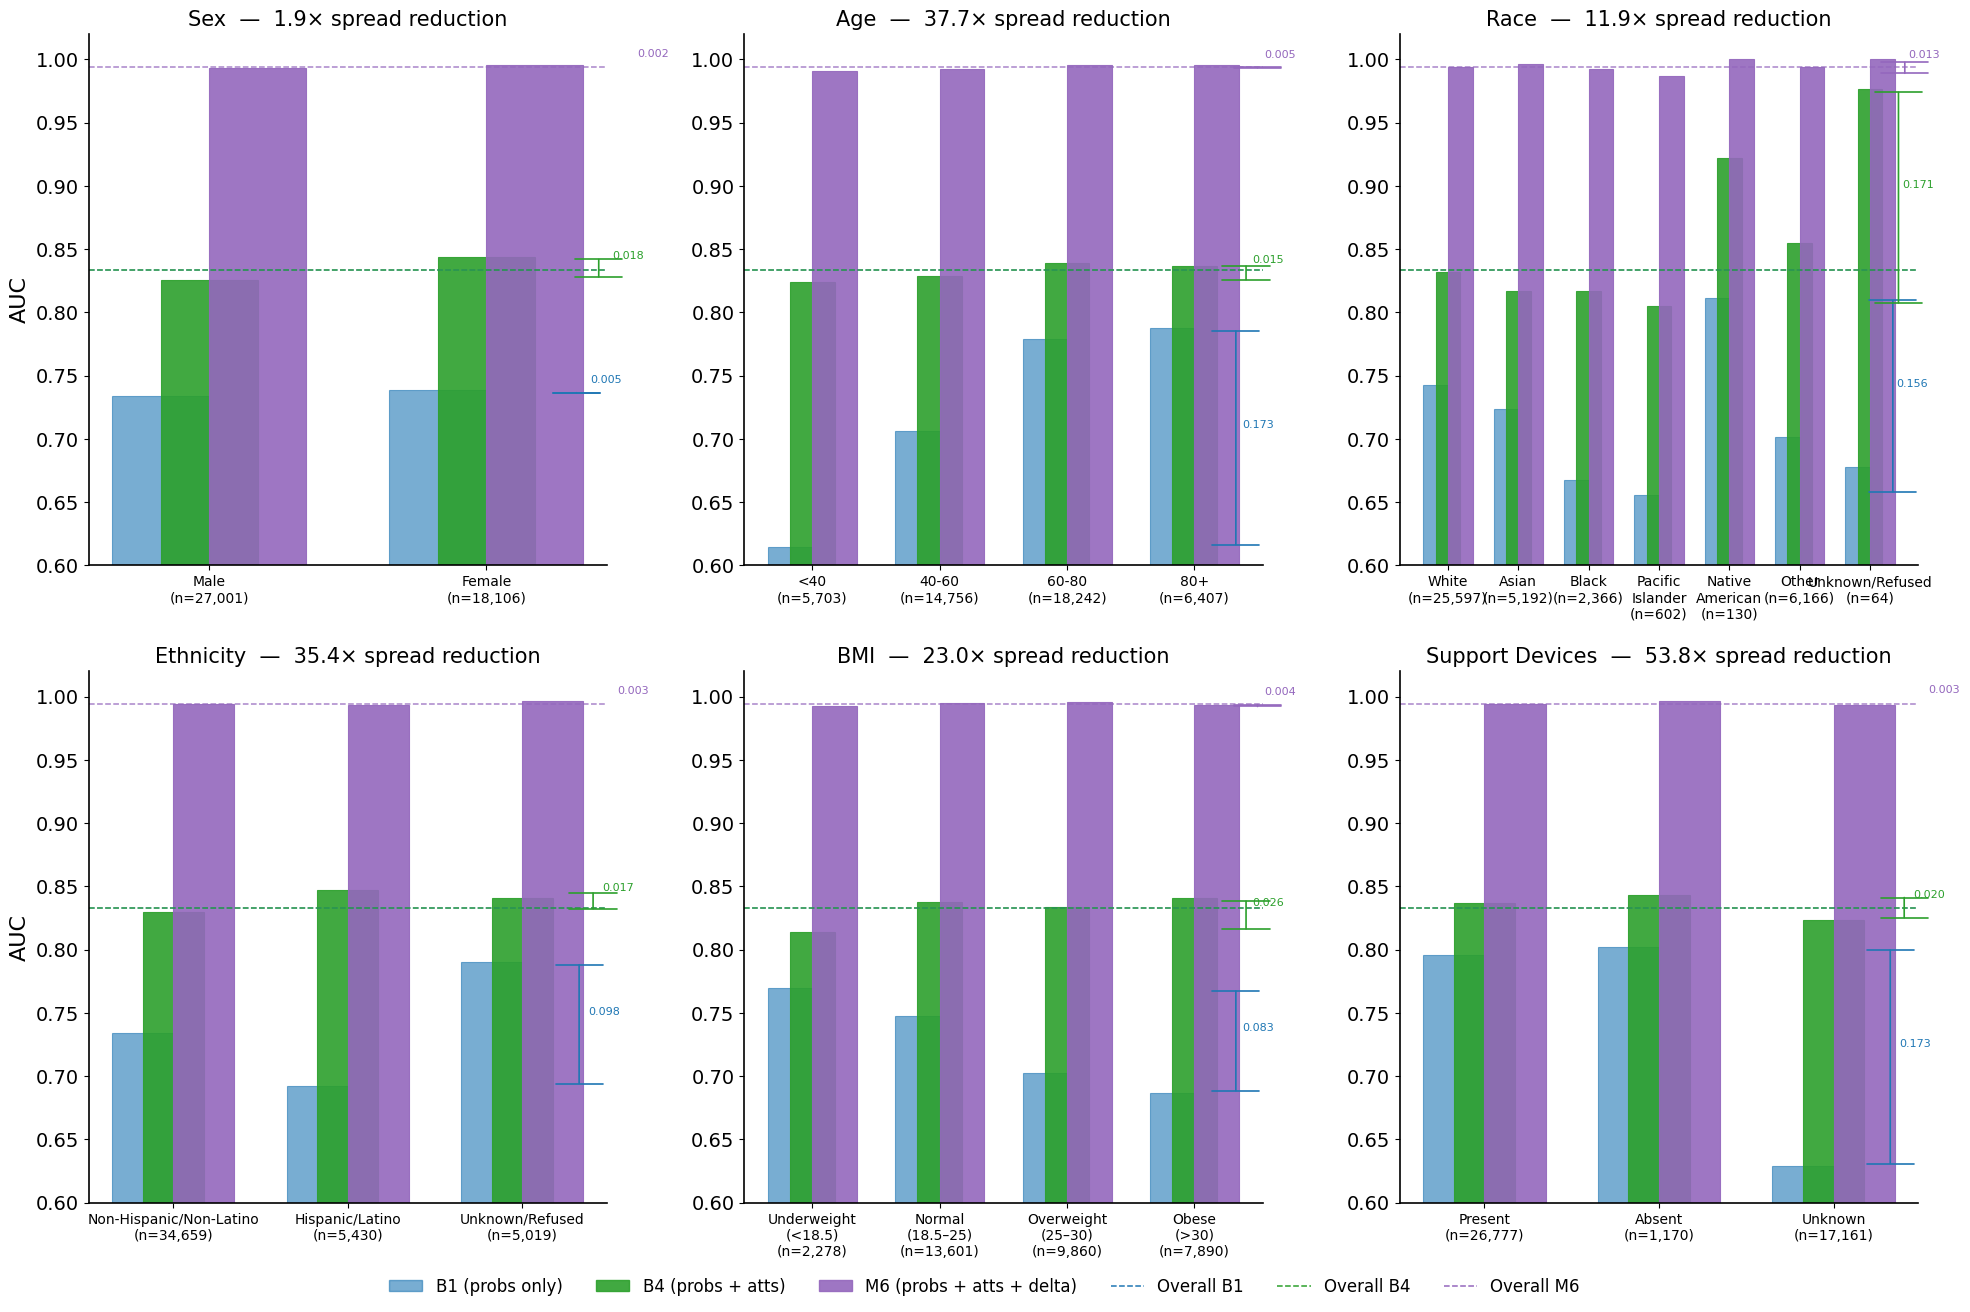

In [ ]:
overall_b1 = roc_auc_score(demographic_df['correct'], demographic_df['LR_B4_prob'])
overall_b4 = roc_auc_score(demographic_df['correct'], demographic_df['LR_B4_prob'])
overall_m6 = roc_auc_score(demographic_df['correct'], demographic_df['LR_M3_prob'])
print(f"\nOverall AUC — B1: {overall_b1:.4f} | M6: {overall_m6:.4f}")

# Choose colours fro viridis, blue for B1 and purple for M6
# B1 BLUE
B1_COLOR = '#1f77b4'  # Matplotlib default blue
B4_COLOR = '#2ca02c'  # Matplotlib default green
M6_COLOR = '#9467bd'  # Matplotlib default purple

# mpatches
import matplotlib.patches as mpatches

plt.rcParams.update({
    'font.size': 17,
    'axes.linewidth': 1.2,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 15,
})


def plot_all_subgroups(subgroup_data, spreads, overall_b1, overall_b4, overall_m6):
    keys = list(subgroup_data.keys())  # Sex, Age, Race, Ethnicity, BMI, Support Devices
    fig, axes = plt.subplots(2, 3, figsize=(20, 13))
    axes_flat = axes.flatten()

    for i, (title, data) in enumerate(subgroup_data.items()):
        ax = axes_flat[i]
        groups  = data['groups']
        b1_vals = data['b1']
        b4_vals = data['b4']
        m6_vals = data['m6']
        x = np.arange(len(groups))
        print(f"{title} groups: {groups}")
        w = 0.35

        ax.bar(x - w/2, b1_vals, w, color=B1_COLOR, alpha=0.6,
               edgecolor=B1_COLOR, linewidth=0.8)
        ax.bar(x, b4_vals, w, color=B4_COLOR, alpha=0.9,
               edgecolor=B4_COLOR, linewidth=0.8)
        ax.bar(x + w/2, m6_vals, w, color=M6_COLOR, alpha=0.9,
               edgecolor=M6_COLOR, linewidth=0.8) 

        ax.axhline(overall_b1, color=B1_COLOR, linestyle='--', linewidth=1.1, alpha=0.8)
        ax.axhline(overall_b4, color=B4_COLOR, linestyle='--', linewidth=1.1, alpha=0.8)
        ax.axhline(overall_m6, color=M6_COLOR, linestyle='--', linewidth=1.1, alpha=0.8)

        # Spread brackets
        x_right = x[-1] + w/2
        for vals, color, x_off in [(b1_vals, B1_COLOR, 0.15), (b4_vals, B4_COLOR, 0.23), (m6_vals, M6_COLOR, 0.32)]:
            ymin, ymax = min(vals), max(vals)
            ax.annotate('', xy=(x_right + x_off, ymin),
                        xytext=(x_right + x_off, ymax),
                        arrowprops=dict(arrowstyle='|-|', color=color, lw=1.2))
            ax.text(x_right + x_off + 0.05, (ymin + ymax) / 2 + 0.01,
                    f'{ymax - ymin:.3f}', va='center', fontsize=8, color=color)

        b1_sp, b4_sp, m6_sp, label = spreads[title]
        ax.set_title(f'{title}  —  {label} spread reduction', fontsize=15)
        ax.set_xticks(x)
        ax.set_xticklabels(groups, fontsize=10)        
        ax.set_ylim(0.6, 1.02)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.2f}'))
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        if i % 3 == 0:
            ax.set_ylabel('AUC')


    legend_elements = [
        mpatches.Patch(facecolor=B1_COLOR, alpha=0.6, edgecolor=B1_COLOR, label='B1 (probs only)'),
        mpatches.Patch(facecolor=B4_COLOR, alpha=0.9, edgecolor=B4_COLOR, label='B4 (probs + atts)'),
        mpatches.Patch(facecolor=M6_COLOR, alpha=0.9, edgecolor=M6_COLOR, label='M6 (probs + atts + delta)'),
        plt.Line2D([0], [0], color=B1_COLOR, linestyle='--', linewidth=1.1, label='Overall B1'),
        plt.Line2D([0], [0], color=B4_COLOR, linestyle='--', linewidth=1.1, label='Overall B4'),
        plt.Line2D([0], [0], color=M6_COLOR, linestyle='--', linewidth=1.1, label='Overall M6'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=6,
               bbox_to_anchor=(0.5, -0.02), fontsize=12, frameon=False)

    plt.tight_layout()
    plt.show()


# ── Build data dicts from your dataframes ─────────────────────────────────────
def build_subgroup_data(auc_df, group_col, group_order, counts):
    return {
        'groups': [f'{g}\n(n={counts[g]:,})' for g in group_order],
        'b1':     [auc_df.loc[auc_df['group'] == g, 'auc_b1'].values[0] for g in group_order],
        'b4':     [auc_df.loc[auc_df['group'] == g, 'auc_b4'].values[0] for g in group_order],
        'm6':     [auc_df.loc[auc_df['group'] == g, 'auc_m6'].values[0] for g in group_order],
    }

# Count per group
sex_counts  = demographic_df['sex'].value_counts().to_dict()
age_counts  = demographic_df['age_group'].value_counts().to_dict()
race_counts = demographic_df['race'].dropna().value_counts().to_dict()
eth_counts  = demographic_df['ethnicity'].dropna().value_counts().to_dict()
bmi_counts  = demographic_df['bmi_group'].dropna().value_counts().to_dict()
support_counts = demographic_df['Support Devices'].dropna().value_counts().to_dict()


subgroup_data = {
    'Sex':       build_subgroup_data(sex_aucs,       'group', ['Male', 'Female'],                                sex_counts),
    'Age':       build_subgroup_data(age_aucs,        'group', ['<40', '40-60', '60-80', '80+'],                 age_counts),
    'Race': build_subgroup_data(
    race_aucs,
    'group',
    ['White', 'Asian', 'Black', 'Pacific\nIslander',
     'Native\nAmerican', 'Other', 'Unknown/Refused'],
    race_counts
),
    'Ethnicity': build_subgroup_data(ethnicity_aucs,  'group', ['Non-Hispanic/Non-Latino', 'Hispanic/Latino', 'Unknown/Refused'],   eth_counts),
    'BMI':       build_subgroup_data(bmi_aucs,        'group', ['Underweight\n(<18.5)', 'Normal\n(18.5–25)',
                                                                 'Overweight\n(25–30)', 'Obese\n(>30)'],         bmi_counts),
    'Support Devices': build_subgroup_data(support_aucs, 'group', ['Present', 'Absent', 'Unknown'], support_counts)}

spreads = {
    name: (df['auc_b1'].max() - df['auc_b1'].min(),
           df['auc_b4'].max() - df['auc_b4'].min(),
           df['auc_m6'].max() - df['auc_m6'].min(),
           f"{(df['auc_b1'].max()-df['auc_b1'].min()) / (df['auc_m6'].max()-df['auc_m6'].min()):.1f}×")
    for name, df in [('Sex', sex_aucs), ('Age', age_aucs), ('Race', race_aucs),
                     ('Ethnicity', ethnicity_aucs), ('BMI', bmi_aucs), ('Support Devices', support_aucs)]
}

plot_all_subgroups(subgroup_data, spreads, overall_b1, overall_b4, overall_m6)

In [ ]:
# Print the spreads in text form
print("=== Subgroup AUC Spreads ===")
for name, (b1_spread, b4_spread, m6_spread, reduction) in spreads.items():
    print(f"{name:12s} — B1 spread: {b1_spread:.4f} | B4 spread: {b4_spread:.4f} | M6 spread: {m6_spread:.4f} | reduction: {reduction}")

print

=== Subgroup AUC Spreads ===
Sex          — B1 spread: 0.0047 | B4 spread: 0.0182 | M6 spread: 0.0024 | reduction: 1.9×
Age          — B1 spread: 0.1733 | B4 spread: 0.0151 | M6 spread: 0.0046 | reduction: 37.7×
Race         — B1 spread: 0.1559 | B4 spread: 0.1709 | M6 spread: 0.0131 | reduction: 11.9×
Ethnicity    — B1 spread: 0.0983 | B4 spread: 0.0169 | M6 spread: 0.0028 | reduction: 35.4×
BMI          — B1 spread: 0.0833 | B4 spread: 0.0263 | M6 spread: 0.0036 | reduction: 23.0×
Support Devices — B1 spread: 0.1732 | B4 spread: 0.0203 | M6 spread: 0.0032 | reduction: 53.8×


## Subgroup Risk Coverage

> Using the functions from c2_cv_rejection_analysis_new_split.py

In [79]:
plt.rcParams.update({
    'font.size': 17,
    'axes.linewidth': 1.2,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 15,
})

In [80]:
import sys
sys.path.append('/zhome/d0/a/221493/thesis/code')
from c2_cv_rejection_analysis_new_split import compute_risk_coverage, compute_selective_accuracy

In [81]:
def valid_groups(df, col, min_n=10):
    return df[col].value_counts()[lambda x: x > min_n].index

In [87]:
demographic_df

,path,effusion_true,effusion_pred,correct,LR_B1_prob,LR_B4_prob,LR_M3_prob,race,ethnicity,recent_bmi,Path,Support Devices,sex,age,bmi_group,age_group
0,CheXpert-v1.0-small/train/patient00008/study1/...,1.0,1,1,0.699597,0.784300,0.999393,White,Non-Hispanic/Non-Latino,25.9,CheXpert-v1.0-small/train/patient00008/study1/...,Present,Male,81.0,Overweight\n(25–30),80+
1,CheXpert-v1.0-small/train/patient00008/study2/...,1.0,1,1,0.603306,0.185356,0.250201,White,Non-Hispanic/Non-Latino,25.9,CheXpert-v1.0-small/train/patient00008/study2/...,Present,Male,81.0,Overweight\n(25–30),80+
3,CheXpert-v1.0-small/train/patient00012/study2/...,0.0,0,1,0.218105,0.432907,0.816978,Other,Non-Hispanic/Non-Latino,30.3,CheXpert-v1.0-small/train/patient00012/study2/...,Present,Female,61.0,Obese\n(>30),60-80
4,CheXpert-v1.0-small/train/patient00012/study1/...,0.0,0,1,0.205762,0.588828,0.995004,Other,Non-Hispanic/Non-Latino,30.3,CheXpert-v1.0-small/train/patient00012/study1/...,Present,Female,61.0,Obese\n(>30),60-80
5,CheXpert-v1.0-small/train/patient00039/study5/...,1.0,1,1,0.609681,0.475905,0.974550,Asian,Non-Hispanic/Non-Latino,19.8,CheXpert-v1.0-small/train/patient00039/study5/...,Present,Female,37.0,Normal\n(18.5–25),<40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45103,CheXpert-v1.0-small/train/patient47326/study15...,1.0,1,1,0.702736,0.926692,0.999964,White,Non-Hispanic/Non-Latino,26.3,CheXpert-v1.0-small/train/patient47326/study15...,Present,Female,44.0,Overweight\n(25–30),40-60
45104,CheXpert-v1.0-small/train/patient47326/study16...,1.0,1,1,0.705788,0.895871,0.999779,White,Non-Hispanic/Non-Latino,26.3,CheXpert-v1.0-small/train/patient47326/study16...,Present,Female,44.0,Overweight\n(25–30),40-60
45105,CheXpert-v1.0-small/train/patient47326/study6/...,1.0,1,1,0.704179,0.782109,0.998765,White,Non-Hispanic/Non-Latino,26.3,CheXpert-v1.0-small/train/patient47326/study6/...,Present,Female,44.0,Overweight\n(25–30),40-60
45106,CheXpert-v1.0-small/train/patient47326/study14...,1.0,1,1,0.703032,0.870472,0.999942,White,Non-Hispanic/Non-Latino,26.3,CheXpert-v1.0-small/train/patient47326/study14...,Present,Female,44.0,Overweight\n(25–30),40-60


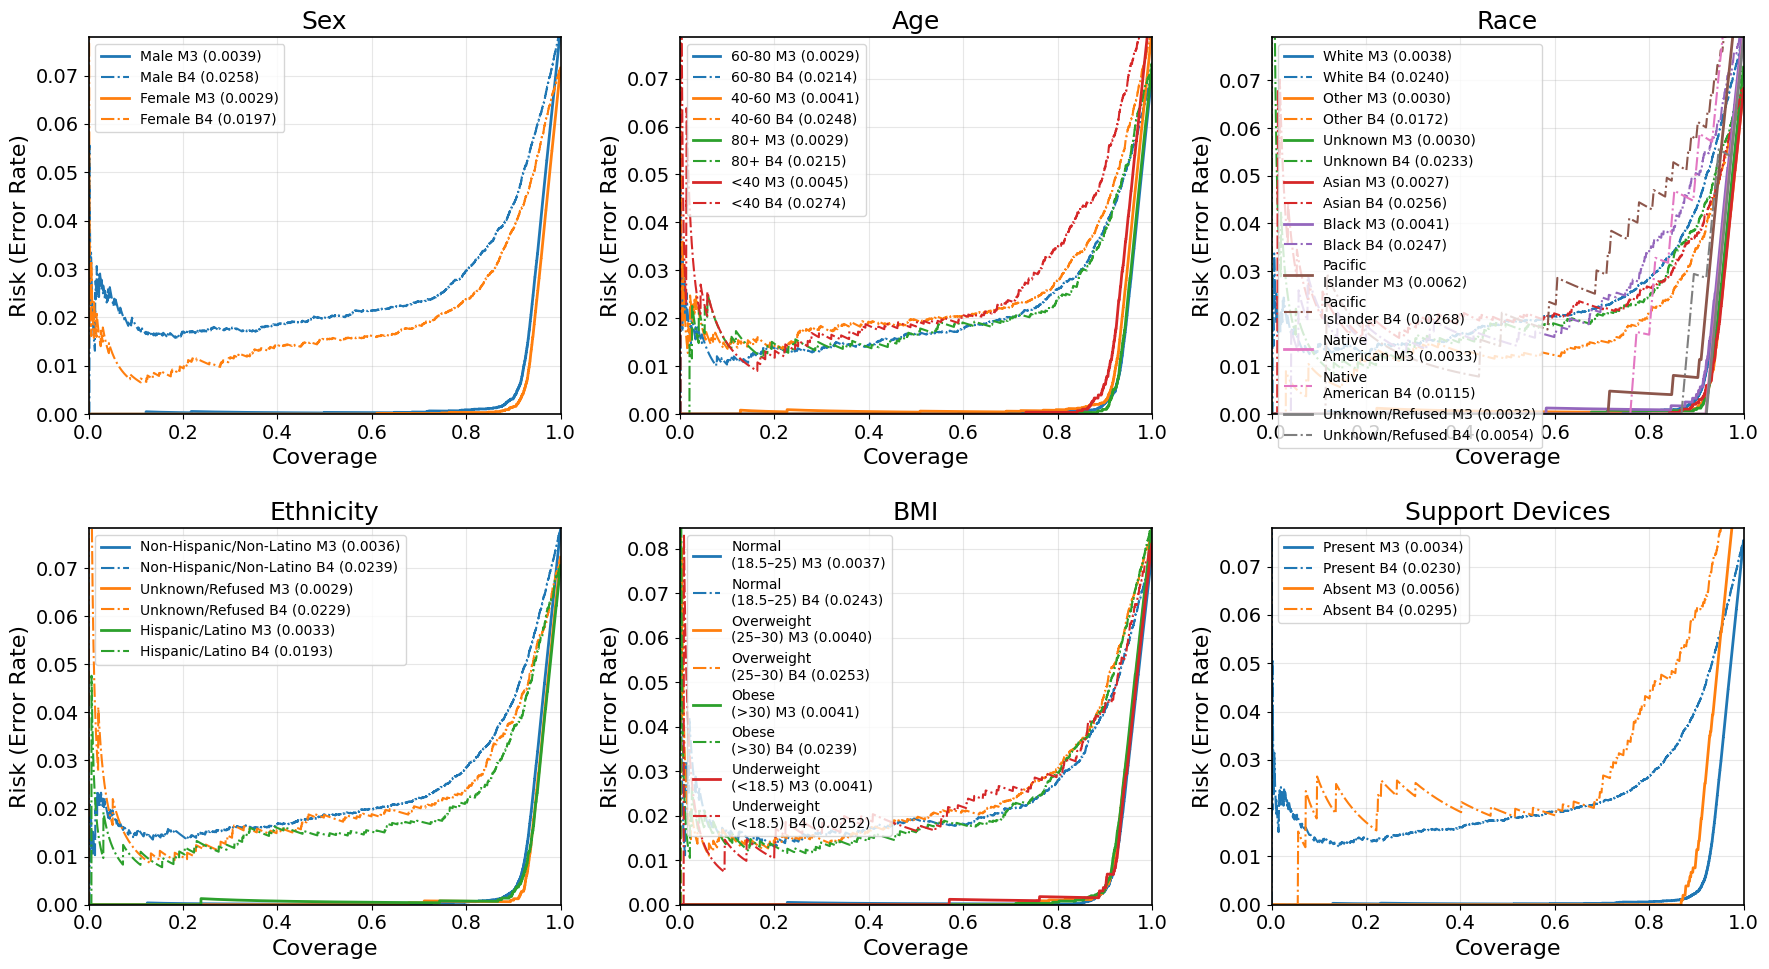

In [90]:

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()

categories = {
    'Sex':       'sex',
    'Age':       'age_group',
    'Race':      'race',
    'Ethnicity': 'ethnicity',
    'BMI':       'bmi_group',
    'Support Devices': 'Support Devices'
}

# We need to filter out support Devices = Unkknown since it's a mix of missing and uncertain, and we don't want to plot it as its own group
demographic_df = demographic_df[demographic_df['Support Devices'] != 'Unknown']

GROUP_COLORS = plt.cm.tab10.colors  # enough distinct colors

for ax, (title, col) in zip(axes_flat, categories.items()):
    all_risks = []
    groups = list(valid_groups(demographic_df, col))
    
    for color, group in zip(GROUP_COLORS, groups):
        mask = demographic_df[col] == group
        correct = demographic_df.loc[mask, 'correct'].values
        
        coverage_m3, risk_m3, aurc_m3 = compute_risk_coverage(demographic_df.loc[mask, 'LR_M3_prob'].values, correct)
        coverage_b4, risk_b4, aurc_b4 = compute_risk_coverage(demographic_df.loc[mask, 'LR_B4_prob'].values, correct)
        #coverage_b1, risk_b1, aurc_b1 = compute_risk_coverage(demographic_df.loc[mask, 'LR_B1_prob'].values, correct)
        
        all_risks.extend(risk_m3)
        all_risks.extend(risk_b4)
        #all_risks.extend(risk_b1)
        
        ax.plot(coverage_m3, risk_m3, color=color, ls='-',  lw=2, label=f'{group} M3 ({aurc_m3:.4f})')
        ax.plot(coverage_b4, risk_b4, color=color, ls='-.', lw=1.5, label=f'{group} B4 ({aurc_b4:.4f})')
        #ax.plot(coverage_b1, risk_b1, color=color, ls='--', lw=1.5, label=f'{group} B1 ({aurc_b1:.4f})')
    
    ymin = np.percentile(all_risks, 1)
    ymax = np.percentile(all_risks, 99)
    margin = (ymax - ymin) * 0.1
    ax.set_ylim(max(0, ymin - margin), ymax + margin)
    
    ax.set_title(title)
    ax.set_xlabel('Coverage')
    ax.set_ylabel('Risk (Error Rate)')  
    ax.set_xlim(0, 1)
    ax.legend(fontsize=8)
    # legend to top left inside the plot
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

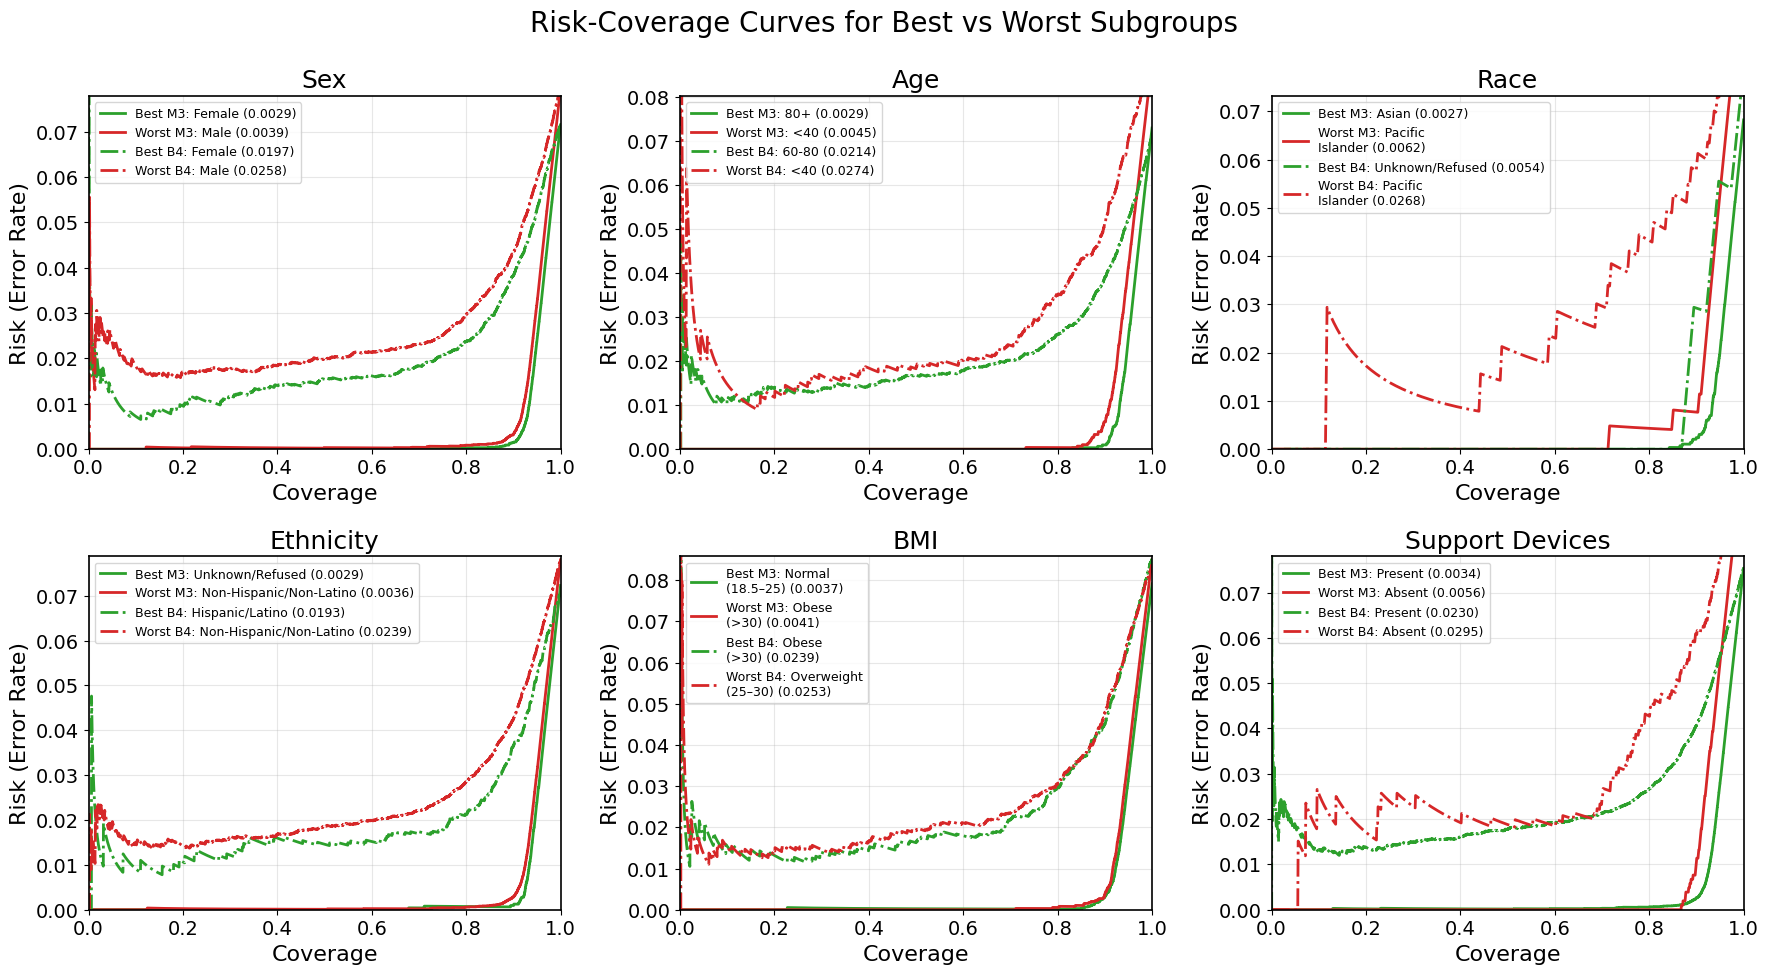

In [95]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()

categories = {
    'Sex':       'sex',
    'Age':       'age_group',
    'Race':      'race',
    'Ethnicity': 'ethnicity',
    'BMI':       'bmi_group',
    'Support Devices': 'Support Devices'
}

# Filter out Unknown support devices
demographic_df = demographic_df[demographic_df['Support Devices'] != 'Unknown']

GROUP_COLORS = {
    'best': 'tab:green',
    'worst': 'tab:red'
}

for ax, (title, col) in zip(axes_flat, categories.items()):

    groups = list(valid_groups(demographic_df, col))

    # Store AURCs for each group/config
    group_metrics = []

    for group in groups:
        mask = demographic_df[col] == group
        correct = demographic_df.loc[mask, 'correct'].values

        coverage_m3, risk_m3, aurc_m3 = compute_risk_coverage(
            demographic_df.loc[mask, 'LR_M3_prob'].values,
            correct
        )

        coverage_b4, risk_b4, aurc_b4 = compute_risk_coverage(
            demographic_df.loc[mask, 'LR_B4_prob'].values,
            correct
        )

        group_metrics.append({
            'group': group,

            'M3': {
                'coverage': coverage_m3,
                'risk': risk_m3,
                'aurc': aurc_m3
            },

            'B4': {
                'coverage': coverage_b4,
                'risk': risk_b4,
                'aurc': aurc_b4
            }
        })

    all_risks = []

    # Plot BEST vs WORST for each config separately
    for model_name, linestyle in [('M3', '-'), ('B4', '-.')]:
        
        # Find best/worst AURC groups
        best_group = min(group_metrics, key=lambda x: x[model_name]['aurc'])
        worst_group = max(group_metrics, key=lambda x: x[model_name]['aurc'])

        # BEST
        ax.plot(
            best_group[model_name]['coverage'],
            best_group[model_name]['risk'],
            color=GROUP_COLORS['best'],
            ls=linestyle,
            lw=2,
            label=f'Best {model_name}: {best_group["group"]} ({best_group[model_name]["aurc"]:.4f})'
        )

        # WORST
        ax.plot(
            worst_group[model_name]['coverage'],
            worst_group[model_name]['risk'],
            color=GROUP_COLORS['worst'],
            ls=linestyle,
            lw=2,
            label=f'Worst {model_name}: {worst_group["group"]} ({worst_group[model_name]["aurc"]:.4f})'
        )

        all_risks.extend(best_group[model_name]['risk'])
        all_risks.extend(worst_group[model_name]['risk'])

    ymin = np.percentile(all_risks, 1)
    ymax = np.percentile(all_risks, 99)
    margin = (ymax - ymin) * 0.1

    ax.set_ylim(max(0, ymin - margin), ymax + margin)

    ax.set_title(title)
    ax.set_xlabel('Coverage')
    ax.set_ylabel('Risk (Error Rate)')
    ax.set_xlim(0, 1)

    ax.legend(loc='upper left', fontsize=9)
    ax.grid(alpha=0.3)
# TITLE
plt.suptitle('Risk-Coverage Curves for Best vs Worst Subgroups', fontsize=20)
plt.tight_layout()
plt.show()

---